# Download data and setup data

In [40]:
from pathlib import Path
from matplotlib import pyplot

import requests
import pickle
import gzip
import torch
import math

In [2]:
DATA_PATH = Path("../../data")
PATH = DATA_PATH / "mnist"

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

In [3]:
with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

/var/folders/3n/lkls0g113777s2662csfkxc8fpf_g4/T/ipykernel_32760/60285702.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


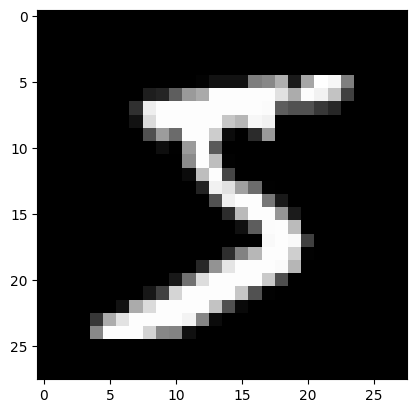

(50000, 784)


In [4]:
pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
pyplot.show()
print(x_train.shape)

In [5]:
x_train, y_train, x_valid, y_valid = map(torch.tensor, (x_train, y_train, x_valid, y_valid))
n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


# The network

In [86]:
torch.randn(784,10)

tensor([[-0.8319, -0.3950,  0.1475,  ...,  1.3732, -1.3722, -0.4092],
        [-1.5039, -0.2112,  2.1413,  ..., -1.9487,  1.2988,  0.3467],
        [ 0.5958, -1.5050,  0.4145,  ...,  0.3578,  0.2735,  0.7859],
        ...,
        [ 2.1931, -0.8991, -0.2028,  ..., -0.5354,  0.4053,  1.4432],
        [-1.0318,  0.8998,  0.9033,  ...,  1.1645,  0.8937, -1.3477],
        [-0.1463, -0.7330, -0.1298,  ...,  0.6414,  1.2862,  0.2910]])

In [41]:
weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

For almost every ML model the basic formula for a single (hidden) layer is 
#### $ \textrm{layer}_{n} = \textrm{transformation}(\textrm{layer}_{n-1} * \textrm{weight}_{n} + \textrm{bias}_{n}) $

In our case we will apply a log softmax transformation to our first layer

#### $\textrm{LogSoftmax}(x_{i}) = log \Bigg(\frac{exp(x_{i})}{\sum _{j} x_{j}} \Bigg) $
simplified in code to:
#### $\textrm{LogSoftmax}(x_{i}) = x_{i} - log(\sum _{j} exp(x_{j})) = x_{i} - LSE(x)$ 

In [73]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
    return log_softmax(xb @ weights + bias)

In [74]:
bs = 64

xb = x_train[0:bs]
preds = model(xb)
preds[0], preds.shape
print(preds[0], preds.shape)

tensor([ -7.3000, -14.0194,  -8.5468,  -2.1552, -15.1842,  -0.1257, -11.8023,
         -6.8545,  -8.4694,  -9.6066], grad_fn=<SelectBackward0>) torch.Size([64, 10])


In [77]:
def nll(pred, target):
    return -pred[range(target.shape[0]), target].mean()

loss_func = nll

In [78]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

tensor(0.1919, grad_fn=<NegBackward0>)


In [79]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [80]:
print(accuracy(preds, yb))

tensor(0.9531)


In [81]:
lr = 0.5
epochs = 2

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        start_i = i*bs
        end_i = start_i + bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

In [82]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0613, grad_fn=<NegBackward0>) tensor(1.)


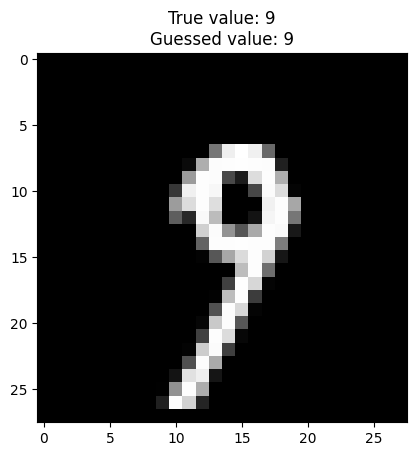

In [85]:
i = 20
selected_val = x_valid[i]
prediction = model(selected_val)
pyplot.imshow(selected_val.reshape((28, 28)), cmap="gray")
pyplot.title(f"True value: {y_valid[i]}\nGuessed value: {prediction.argmax()}")
pyplot.show()